## 0 · Install Dependencies


In [1]:
!pip install torch torchvision nibabel pandas scikit-learn tqdm matplotlib scipy optuna -q


## 1 · Imports


In [2]:
import os, sys, glob, random, warnings, copy
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm.notebook import tqdm

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 34
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU   : NVIDIA GeForce RTX 3090
VRAM  : 25.4 GB


## 2 · Configuration

> **MedicalNet — ResNet-10**
> Pretrained on 8 segmentation datasets of 3D medical images (MSD challenge).
> Native **1-channel** input — no adaptation needed.
> Input shape: any size, but pretraining used ~`(D, H, W)` at 1×1×1 mm.
> We use `(96, 112, 96)` to match the MedicalNet reference preprocessing.

> **Memory guide**
> | `TARGET_SHAPE` | VRAM approx (batch=2) |
> |---|---|
> | `(96, 112, 96)` | ~4 GB |
> | `(128, 128, 128)` | ~8 GB |


In [3]:
CSV_PATH        = "OASIS3_metadata_final.csv"
IMAGE_DIR       = "."
MEDICALNET_DIR  = "MedicalNet_weights"   # folder where weights will be saved
MEDICALNET_URL  = (
    "https://huggingface.co/TencentMedicalNet/MedicalNet-Resnet10/resolve/main/"
    "resnet_10_23dataset.pth"
)

TARGET_SHAPE = (96, 112, 96)   # (D, H, W) — MedicalNet reference shape

# Optuna settings
N_TRIALS         = 30
EPOCHS_PER_TRIAL = 5
EPOCHS_FINAL     = 50


## 3 · Download MedicalNet Weights

MedicalNet ResNet-10 pretrained on 23 medical segmentation datasets (8 from MSD + others).
Weights are hosted on HuggingFace and downloaded automatically on first run.


In [4]:
import urllib.request

os.makedirs(MEDICALNET_DIR, exist_ok=True)
weights_path = os.path.join(MEDICALNET_DIR, "resnet_10_23dataset.pth")

if not os.path.exists(weights_path):
    print("Downloading MedicalNet ResNet-10 weights (~180 MB)...")
    urllib.request.urlretrieve(MEDICALNET_URL, weights_path)
    print(f"Saved to {weights_path}")
else:
    print(f"Weights already present at {weights_path}")


Weights already present at MedicalNet_weights/resnet_10_23dataset.pth


## 4 · Load Metadata & Create Labels


In [5]:
df = pd.read_csv(CSV_PATH)
print(f"Raw CSV rows: {len(df)}")

df["label"] = df["DEMENTED"].astype(int)
df = df[(df["DEMENTED"] + df["NORMCOG"]) == 1]
print(f"After consistency filter: {len(df)}")

display(df[["Subject_ID", "DEMENTED", "NORMCOG", "label"]].head())
print("\nLabel distribution:")
display(df["label"].value_counts().rename({0: "Normal", 1: "Demented"}))


Raw CSV rows: 1086
After consistency filter: 1086


,Subject_ID,DEMENTED,NORMCOG,label
0,OAS30001,0,1,0
1,OAS30002,0,1,0
2,OAS30003,0,1,0
3,OAS30004,0,1,0
4,OAS30005,0,1,0



Label distribution:


label
Normal      686
Demented    400
Name: count, dtype: int64

## 5 · Match Subjects → NIfTI Files


In [6]:
all_images = glob.glob(os.path.join(IMAGE_DIR, "**/*.nii.gz"), recursive=True)
print(f"NIfTI files found: {len(all_images)}")

subject_to_path = {}
for img_path in all_images:
    filename = os.path.basename(img_path)
    for subject_id in df["Subject_ID"].unique():
        if subject_id in filename:
            subject_to_path[subject_id] = img_path
            break

df["image_path"] = df["Subject_ID"].map(subject_to_path)
missing = df["image_path"].isna().sum()
print(f"Subjects without MRI: {missing}")
df = df.dropna(subset=["image_path"])
print(f"Final dataset size  : {len(df)}")


NIfTI files found: 1188
Subjects without MRI: 0
Final dataset size  : 1086


## 6 · Train / Validation / Test Split — Stratified by Label, Age & Gender (60 / 20 / 20)


In [7]:
# Stratify by label + age bin (< 75 / ≥ 75) + gender (1=male, 2=female):
df["age_bin"] = (df["Age"] >= 75).astype(int)
df["strat"]   = (
    df["label"].astype(str) + "_" +
    df["age_bin"].astype(str) + "_" +
    df["Gender"].astype(str)
)

print("Stratum distribution:\n", df["strat"].value_counts())

train_df, temp_df = train_test_split(
    df, test_size=0.4, stratify=df["strat"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["strat"], random_state=SEED
)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n── {name} ──")
    print(split["label"].value_counts(normalize=True).rename({0: "Normal", 1: "Demented"}))
    print(f"Age mean : {split['Age'].mean():.1f}  std: {split['Age'].std():.1f}")
    print(f"Gender   : {split['Gender'].value_counts(normalize=True).rename({1: 'Male', 2: 'Female'}).to_dict()}")


Stratum distribution:
 strat
0_0_2    343
0_0_1    235
1_1_1    119
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64

Train: 651  |  Val: 217  |  Test: 218
Total: 1086

── Train ──
label
Normal      0.632873
Demented    0.367127
Name: proportion, dtype: float64
Age mean : 70.7  std: 9.2
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}

── Val ──
label
Normal      0.631336
Demented    0.368664
Name: proportion, dtype: float64
Age mean : 70.2  std: 9.6
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}

── Test ──
label
Normal      0.62844
Demented    0.37156
Name: proportion, dtype: float64
Age mean : 70.1  std: 9.1
Gender   : {'Female': 0.5458715596330275, 'Male': 0.4541284403669725}


## 7 · Dataset Class


In [8]:
def load_and_preprocess(path, target_shape=TARGET_SHAPE):
    nii    = nib.load(path)
    volume = nii.get_fdata(dtype=np.float32)
    volume = np.squeeze(volume)
    zoom_factors = [t / s for t, s in zip(target_shape, volume.shape)]
    volume = zoom(volume, zoom_factors, order=1)
    vmin, vmax = volume.min(), volume.max()
    return (volume - vmin) / (vmax - vmin + 1e-8)


class OASIS3DDataset(Dataset):
    def __init__(self, dataframe, target_shape=TARGET_SHAPE, augment=False):
        self.df           = dataframe.reset_index(drop=True)
        self.target_shape = target_shape
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        volume = load_and_preprocess(row["image_path"], self.target_shape)

        if self.augment:
            if random.random() > 0.5:
                volume = np.flip(volume, axis=0).copy()
            if random.random() > 0.5:
                volume = np.clip(volume + np.random.normal(0, 0.01, volume.shape), 0, 1)

        volume = torch.tensor(volume, dtype=torch.float32).unsqueeze(0)
        label  = torch.tensor(row["label"], dtype=torch.long)

        return volume, label

## 8 · Transfer Learning — MedicalNet ResNet-10 Encoder

**Why MedicalNet ResNet-10:**
- Pretrained on 23 3D medical imaging datasets — learns features directly relevant to brain MRI.
- Native 1-channel input — no channel adaptation needed.
- ResNet-10 is lightweight enough to run on modest GPUs while still being expressive.
- Well-established baseline in Alzheimer classification literature.

**Strategy:**
1. Load ResNet-10 architecture and pretrained weights.
2. Remove the original segmentation head — keep only the encoder (all ResNet layers up to global average pool).
3. Freeze encoder during Optuna — only the FC classifier head is optimized.
4. Fine-tune the full network after Optuna with a lower learning rate.

| Component | Optuna phase | Final training phase 1 | Final training phase 2 |
|---|---|---|---|
| ResNet-10 encoder | Frozen | Frozen | Unfrozen (fine-tune) |
| FC classifier | Trainable | Trainable | Trainable |


In [9]:
# ── MedicalNet ResNet-10 architecture ──────────────────────────────────────
# Reproduced from the official MedicalNet repo (Tencent):
# https://github.com/Tencent/MedicalNet

def conv3x3x3(in_planes, out_planes, stride=1, dilation=1):
    return nn.Conv3d(
        in_planes, out_planes, kernel_size=3,
        dilation=dilation, stride=stride, padding=dilation, bias=False
    )


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, dilation=1, downsample=None):
        super().__init__()
        self.conv1      = conv3x3x3(in_planes, planes, stride=stride, dilation=dilation)
        self.bn1        = nn.BatchNorm3d(planes)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = conv3x3x3(planes, planes, dilation=dilation)
        self.bn2        = nn.BatchNorm3d(planes)
        self.downsample = downsample
        self.stride     = stride
        self.dilation   = dilation

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            residual = self.downsample(x)
        return self.relu(out + residual)


class ResNet(nn.Module):
    def __init__(self, block, layers, shortcut_type="B"):
        super().__init__()
        self.in_planes = 64
        self.conv1     = nn.Conv3d(1, 64, kernel_size=7, stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
        self.bn1       = nn.BatchNorm3d(64)
        self.relu      = nn.ReLU(inplace=True)
        self.maxpool   = nn.MaxPool3d(kernel_size=(3, 3, 3), stride=2, padding=1)
        self.layer1    = self._make_layer(block, 64,  layers[0], shortcut_type)
        self.layer2    = self._make_layer(block, 128, layers[1], shortcut_type, stride=2)
        self.layer3    = self._make_layer(block, 256, layers[2], shortcut_type, stride=1, dilation=2)
        self.layer4    = self._make_layer(block, 512, layers[3], shortcut_type, stride=1, dilation=4)

        # Weight init:
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1); m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, shortcut_type, stride=1, dilation=1):
        downsample = None
        if stride != 1 or self.in_planes != planes * block.expansion:
            if shortcut_type == "A":
                downsample = lambda x: F.pad(
                    x[:, :, ::stride, ::stride, ::stride],
                    (0, 0, 0, 0, 0, 0, 0, planes * block.expansion - self.in_planes)
                )
            else:
                downsample = nn.Sequential(
                    nn.Conv3d(self.in_planes, planes * block.expansion,
                              kernel_size=1, stride=stride, bias=False),
                    nn.BatchNorm3d(planes * block.expansion),
                )
        layers = [block(self.in_planes, planes, stride=stride, dilation=dilation, downsample=downsample)]
        self.in_planes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_planes, planes, dilation=dilation))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x   # (B, 512, D', H', W')


def resnet10():
    """MedicalNet ResNet-10: 4 stages, 1 block each."""
    return ResNet(BasicBlock, [1, 1, 1, 1])


# ── TransferNet ─────────────────────────────────────────────────────────────

class TransferNet(nn.Module):
    """
    MedicalNet ResNet-10 encoder + custom FC classifier head.
    """
    def __init__(self, encoder, gap, classifier):
        super().__init__()
        self.encoder    = encoder
        self.gap        = gap
        self.classifier = classifier

    def forward(self, x):
        features = self.encoder(x)          # (B, 512, D', H', W')
        pooled   = self.gap(features)        # (B, 512, 1, 1, 1)
        return self.classifier(pooled)       # (B, 2)


# ── build_transfer_model ─────────────────────────────────────────────────────

def build_transfer_model(config, freeze_encoder=True):
    """
    Build the MedicalNet transfer learning model.

    Expected config keys:
        n_fc_layers (int)  : number of hidden FC layers (0 = direct linear).
        fc_units    (int)  : neurons per hidden FC layer.
        dropout     (float): dropout probability.

    Args:
        freeze_encoder (bool): freeze encoder weights if True (Optuna phase).
    """

    ### 1. Build ResNet-10 encoder ###
    encoder = resnet10()

    ### 2. Load pretrained MedicalNet weights ###
    state_dict = torch.load(weights_path, map_location=DEVICE)

    # MedicalNet checkpoints are wrapped under "state_dict" key:
    if "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]

    # Strip "module." prefix if saved with DataParallel:
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # Load only encoder weights (ignore segmentation head keys):
    encoder_keys = {k: v for k, v in state_dict.items() if not k.startswith("conv_seg")}
    missing, unexpected = encoder.load_state_dict(encoder_keys, strict=False)
    # print(f"Pretrained weights loaded  — missing: {len(missing)}, unexpected: {len(unexpected)}")

    ### 3. Freeze / unfreeze encoder ###
    for param in encoder.parameters():
        param.requires_grad = not freeze_encoder
    # print("Encoder frozen." if freeze_encoder else "Encoder unfrozen (fine-tuning mode).")

    ### 4. Build FC classifier ###
    gap         = nn.AdaptiveAvgPool3d(1)
    encoder_out = 512   # ResNet-10 last layer outputs 512 channels

    fc_layers   = []
    in_features = encoder_out

    for _ in range(config["n_fc_layers"]):
        fc_layers += [
            nn.Linear(in_features, config["fc_units"]),
            nn.ReLU(inplace=True),
            nn.Dropout(config["dropout"]),
        ]
        in_features = config["fc_units"]

    fc_layers.append(nn.Linear(in_features, 2))   # 2 clases: Normal / Demented
    classifier = nn.Sequential(nn.Flatten(), *fc_layers)

    ### 5. Assemble and move to device ###
    model     = TransferNet(encoder, gap, classifier).to(DEVICE)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    # print(f"Frozen parameters    : {frozen:,}")
    # print(f"Trainable parameters : {trainable:,}")
    return model

## 9 · Training & Evaluation


In [10]:
import copy
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve
)


def train_model(model, train_loader, val_loader, epochs, lr, criterion, device,
                scheduler_name="ReduceLROnPlateau", patience=15, min_delta=0.0, plots=True, verbose=True):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    if scheduler_name == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=3
        )
    elif scheduler_name == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs
        )
    else:
        scheduler = None

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "val_precision": [], "val_recall": [], "val_f1": [], "val_auc": [],
    }

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in tqdm(range(epochs), desc="Epochs"):

        model.train()
        train_correct = 0
        train_total = 0
        epoch_t_loss = 0.0

        for volumes, labels in train_loader:
            volumes = volumes.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(volumes)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_t_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            train_total += labels.size(0)
            train_correct += (preds == labels).sum().item()

        epoch_train_acc = 100 * train_correct / train_total
        epoch_train_loss = epoch_t_loss / len(train_loader)

        history["train_acc"].append(epoch_train_acc)
        history["train_loss"].append(epoch_train_loss)

        model.eval()
        val_correct = 0
        val_total = 0
        epoch_v_loss = 0.0

        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for volumes, labels in val_loader:
                volumes = volumes.to(device)
                labels = labels.to(device).long()

                outputs = model(volumes)
                loss = criterion(outputs, labels)

                epoch_v_loss += loss.item()

                probs = torch.softmax(outputs, dim=1)[:, 1]
                preds = torch.argmax(outputs, dim=1)

                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        epoch_val_acc = 100 * val_correct / val_total
        epoch_val_loss = epoch_v_loss / len(val_loader)

        epoch_val_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        epoch_val_auc = roc_auc_score(all_labels, all_probs)

        history["val_acc"].append(epoch_val_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_precision"].append(epoch_val_precision)
        history["val_recall"].append(epoch_val_recall)
        history["val_f1"].append(epoch_val_f1)
        history["val_auc"].append(epoch_val_auc)

        if scheduler_name == "ReduceLROnPlateau" and scheduler is not None:
            scheduler.step(epoch_val_loss)
        elif scheduler_name == "CosineAnnealingLR" and scheduler is not None:
            scheduler.step()

        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | "
                f"Val F1: {epoch_val_f1:.4f}"
            )

    model.load_state_dict(best_model_weights)
    return model, history


def test_model(model, test_loader, device, plot=True, save=False):

    model.eval()

    preds = []
    trues = []
    probs = []

    with torch.no_grad():
        for volumes, labels in test_loader:
            volumes = volumes.to(device)
            labels = labels.to(device).long()

            outputs = model(volumes)

            p = torch.softmax(outputs, dim=1)[:, 1]
            pr = torch.argmax(outputs, dim=1)

            preds.extend(pr.cpu().numpy())
            trues.extend(labels.cpu().numpy())
            probs.extend(p.cpu().numpy())

    preds = np.array(preds)
    trues = np.array(trues)
    probs = np.array(probs)

    acc = accuracy_score(trues, preds)
    precision_macro = precision_score(trues, preds, average="macro", zero_division=0)
    precision_weighted = precision_score(trues, preds, average="weighted", zero_division=0)
    recall_macro = recall_score(trues, preds, average="macro", zero_division=0)
    recall_weighted = recall_score(trues, preds, average="weighted", zero_division=0)
    f1_macro = f1_score(trues, preds, average="macro", zero_division=0)
    f1_weighted = f1_score(trues, preds, average="weighted", zero_division=0)
    auc_score = roc_auc_score(trues, probs)

    print("\n===== TEST METRICS =====")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Macro Precision    : {precision_macro:.4f}")
    print(f"Weighted Precision : {precision_weighted:.4f}")
    print(f"Macro Recall       : {recall_macro:.4f}")
    print(f"Weighted Recall    : {recall_weighted:.4f}")
    print(f"Macro F1-score     : {f1_macro:.4f}")
    print(f"Weighted F1-score  : {f1_weighted:.4f}")
    print(f"ROC AUC            : {auc_score:.4f}")

    labels_names = ["Normal", "Demented"]
    print(classification_report(trues, preds, target_names=labels_names, digits=4))

    if plot:
        cm = confusion_matrix(trues, preds, labels=[0, 1])
        cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

        plt.figure(figsize=(6, 5))
        import seaborn as sns
        sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
                    xticklabels=labels_names, yticklabels=labels_names)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.tight_layout()
        plt.show()

        fpr, tpr, _ = roc_curve(trues, probs)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(trues, probs):.4f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.legend()
        plt.title("ROC Curve")
        plt.show()

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "auc": auc_score
    }

## 10 · Optuna Objective Function

The encoder is **frozen** during Optuna — only the FC classifier head is optimized.
Each trial is fast since backprop only flows through the small head.

### Define Optuna Study


In [11]:
def objective(trial):

    ### 1. Define Fully Connected Hyperparameters ###
    n_fc_layers = trial.suggest_int("n_fc_layers", 0, 3)
    fc_units    = trial.suggest_int("fc_units", 64, 512, step=64)

    ### 2. Other Hyperparameters ###
    dropout     = trial.suggest_float("dropout", 0.1, 0.6)
    batch_size  = trial.suggest_categorical("batch_size", [2, 4, 8])
    augment     = trial.suggest_categorical("augment", [False])
    lr          = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    ### 3. Model config ###
    config = {
        "n_fc_layers": n_fc_layers,
        "fc_units"   : fc_units,
        "dropout"    : dropout,
    }

    model = build_transfer_model(config, freeze_encoder=True)

    ### 4. Loss (MULTICLASS) ###
    criterion = nn.CrossEntropyLoss()

    ### 5. DataLoaders ###
    train_loader = DataLoader(
        OASIS3DDataset(train_df, augment=augment),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True
    )

    val_loader = DataLoader(
        OASIS3DDataset(val_df, augment=False),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )

    ### 6. Training loop ###
    val_f1_history = []

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.1, patience=2
    )

    for epoch in tqdm(range(EPOCHS_PER_TRIAL), desc=f"Trial {trial.number}", leave=False):

        # TRAIN
        model.train()
        for volumes, labels in train_loader:
            volumes = volumes.to(DEVICE)
            labels  = labels.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(volumes), labels)
            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for volumes, labels in val_loader:
                volumes = volumes.to(DEVICE)
                labels  = labels.to(DEVICE)

                logits = model(volumes)
                probs  = torch.softmax(logits, dim=1)

                preds = torch.argmax(probs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())

        epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        val_f1_history.append(epoch_f1)
        scheduler.step(epoch_f1)

        trial.report(epoch_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(val_f1_history[-5:])

### Run Optuna Study

`N_TRIALS` trials with frozen encoder — each trial is fast since only the FC head is trained.


In [12]:
def trial_callback(study, trial):
    print(
        f"Trial #{trial.number:>3} | "
        f"Val F1: {trial.value:.4f} | "
        f"Best so far: {study.best_value:.4f} | "
        f"Params: n_fc={trial.params['n_fc_layers']} "
        f"fc_units={trial.params['fc_units']} "
        f"dropout={trial.params['dropout']:.2f} "
        f"bs={trial.params['batch_size']} "
        f"lr={trial.params['lr']:.2e}"
    )

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, callbacks=[trial_callback])

print(f"\n{'='*50}")
print(f"Best trial  : #{study.best_trial.number}")
print(f"Best val F1 : {study.best_value:.4f}")
print(f"Best params :")
for k, v in study.best_params.items():
    print(f"  {k:<20} = {v}")


Trial #  0 | Val F1: 0.4243 | Best so far: 0.4243 | Params: n_fc=3 fc_units=384 dropout=0.15 bs=8 lr=1.56e-03


Trial #  1 | Val F1: 0.3870 | Best so far: 0.4243 | Params: n_fc=3 fc_units=448 dropout=0.46 bs=4 lr=5.58e-04


Trial #  2 | Val F1: 0.3870 | Best so far: 0.4243 | Params: n_fc=1 fc_units=384 dropout=0.13 bs=2 lr=1.37e-04


Trial #  3 | Val F1: 0.4577 | Best so far: 0.4577 | Params: n_fc=0 fc_units=512 dropout=0.39 bs=8 lr=3.08e-04


Trial #  4 | Val F1: 0.4340 | Best so far: 0.4577 | Params: n_fc=0 fc_units=448 dropout=0.45 bs=8 lr=1.51e-03


...

Trial # 25 | Val F1: 0.2694 | Best so far: 0.5302 | Params: n_fc=0 fc_units=384 dropout=0.27 bs=4 lr=7.90e-03


Trial # 26 | Val F1: 0.3870 | Best so far: 0.5302 | Params: n_fc=1 fc_units=192 dropout=0.20 bs=8 lr=4.14e-03


Trial # 27 | Val F1: 0.3843 | Best so far: 0.5302 | Params: n_fc=0 fc_units=256 dropout=0.41 bs=8 lr=6.67e-03


Trial # 28 | Val F1: 0.3870 | Best so far: 0.5302 | Params: n_fc=1 fc_units=128 dropout=0.52 bs=2 lr=2.42e-03


Trial # 29 | Val F1: 0.4353 | Best so far: 0.5302 | Params: n_fc=0 fc_units=384 dropout=0.33 bs=4 lr=1.75e-03

Best trial  : #18
Best val F1 : 0.5302
Best params :
  n_fc_layers          = 0
  fc_units             = 320
  dropout              = 0.3245770837760739
  batch_size           = 4
  augment              = False
  lr                   = 0.007047051717616189


## 11 · Optuna Visualizations


In [13]:
# !pip install plotly -q

# fig1 = plot_optimization_history(study)
# fig1.update_layout(title="Optimization History — Val F1")
# fig1.show()

# fig2 = plot_param_importances(study)
# fig2.update_layout(title="Hyperparameter Importances")
# fig2.show()

# fig3 = plot_parallel_coordinate(study)
# fig3.update_layout(title="Parallel Coordinate Plot")
# fig3.show()


## 12 · Final Training with Best Hyperparameters

Two-phase training:
1. **Phase 1 — Classifier only** (`freeze_encoder=True`): train the FC head with the encoder frozen.
2. **Phase 2 — Fine-tuning** (`freeze_encoder=False`): unfreeze the full encoder and train end-to-end with `lr / 10`.


In [14]:
best_params = study.best_params
print("Training with:", best_params)

final_config = {
    "n_fc_layers": best_params["n_fc_layers"],
    "fc_units"   : best_params["fc_units"],
    "dropout"    : best_params["dropout"],
}

final_criterion = nn.CrossEntropyLoss()

final_train_loader = DataLoader(
    OASIS3DDataset(train_df, augment=best_params["augment"]),
    batch_size=best_params["batch_size"], shuffle=True, num_workers=2, pin_memory=True
)

final_val_loader = DataLoader(
    OASIS3DDataset(val_df, augment=False),
    batch_size=best_params["batch_size"], shuffle=False, num_workers=2, pin_memory=True
)

final_test_loader = DataLoader(
    OASIS3DDataset(test_df, augment=False),
    batch_size=best_params["batch_size"], shuffle=False, num_workers=2, pin_memory=True
)

Training with: {'n_fc_layers': 0, 'fc_units': 320, 'dropout': 0.3245770837760739, 'batch_size': 4, 'augment': False, 'lr': 0.007047051717616189}


In [15]:
### Phase 1 — Train FC classifier with frozen encoder ###

print("=" * 55)
print("Phase 1: Training FC classifier (encoder frozen)")
print("=" * 55)

final_model = build_transfer_model(final_config, freeze_encoder=True)

final_model, final_history = train_model(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    epochs=EPOCHS_FINAL,
    lr=best_params["lr"],
    criterion=final_criterion,
    device=DEVICE,
    scheduler_name="ReduceLROnPlateau",
    patience=15,
    plots=True,
    verbose=True
)

torch.save(final_model.state_dict(), "best_medicalnet_phase1.pth")
print("Phase 1 model saved to best_medicalnet_phase1.pth")


Phase 1: Training FC classifier (encoder frozen)


Epochs:   2%|▏         | 1/50 [00:29<24:06, 29.53s/it]

Epoch 1/50 | Train Loss: 1.0172 | Val Loss: 1.0982 | Train Acc: 58.53% | Val Acc: 56.22% | Val F1: 0.5621


Epochs:   4%|▍         | 2/50 [00:59<23:41, 29.62s/it]

Epoch 2/50 | Train Loss: 0.9646 | Val Loss: 0.6724 | Train Acc: 54.53% | Val Acc: 63.13% | Val F1: 0.3870


...

Epoch 33/50 | Train Loss: 0.6113 | Val Loss: 0.5951 | Train Acc: 66.97% | Val Acc: 69.12% | Val F1: 0.5791


Epochs:  68%|██████▊   | 34/50 [16:50<07:54, 29.66s/it]

Epoch 34/50 | Train Loss: 0.6224 | Val Loss: 0.5934 | Train Acc: 65.44% | Val Acc: 73.73% | Val F1: 0.6700


Epochs:  68%|██████▊   | 34/50 [17:20<08:09, 30.60s/it]


Phase 1 model saved to best_medicalnet_phase1.pth


In [17]:
### Phase 2 — Fine-tuning: unfreeze encoder ###

print("=" * 55)
print("Phase 2: Fine-tuning (encoder unfrozen)")
print("=" * 55)

# Load best Phase 1 weights:
final_model.load_state_dict(torch.load("best_medicalnet_phase1.pth", map_location=DEVICE))

# Unfreeze all parameters:
for param in final_model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
print(f"Trainable parameters (fine-tuning): {trainable:,}")

# Use lr / 10 to avoid destroying pretrained features:
fine_tune_lr = best_params["lr"] / 10

final_model, finetune_history = train_model(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    epochs=EPOCHS_FINAL,
    lr=fine_tune_lr,
    criterion=final_criterion,
    device=DEVICE,
    scheduler_name="ReduceLROnPlateau",
    patience=15,
    plots=True,
    verbose=True
)

torch.save(final_model.state_dict(), "best_medicalnet_finetuned.pth")
print("Fine-tuned model saved to best_medicalnet_finetuned.pth")


Phase 2: Fine-tuning (encoder unfrozen)
Trainable parameters (fine-tuning): 14,356,546


Epochs:   2%|▏         | 1/50 [00:29<24:01, 29.42s/it]

Epoch 1/50 | Train Loss: 0.7041 | Val Loss: 0.6310 | Train Acc: 60.37% | Val Acc: 63.13% | Val F1: 0.3870


Epochs:   4%|▍         | 2/50 [00:58<23:34, 29.46s/it]

Epoch 2/50 | Train Loss: 0.6442 | Val Loss: 0.9001 | Train Acc: 63.29% | Val Acc: 39.63% | Val F1: 0.3169


...

Epoch 32/50 | Train Loss: 0.5095 | Val Loss: 0.4711 | Train Acc: 75.27% | Val Acc: 77.88% | Val F1: 0.7539


Epochs:  66%|██████▌   | 33/50 [16:17<08:23, 29.60s/it]

Epoch 33/50 | Train Loss: 0.5067 | Val Loss: 0.4718 | Train Acc: 74.65% | Val Acc: 77.42% | Val F1: 0.7496


Epochs:  66%|██████▌   | 33/50 [16:47<08:39, 30.53s/it]


Fine-tuned model saved to best_medicalnet_finetuned.pth


## 13 · Test Set Evaluation


In [18]:
# best_params = {
#     "n_fc_layers": 0,
#     "fc_units": 448,
#     "dropout": 0.4315702240505588,
#     "batch_size": 4,
#     "augment": False,
#     "lr": 0.007220682903754499
# }

# final_config = {
#     "n_fc_layers": best_params["n_fc_layers"],
#     "fc_units": best_params["fc_units"],
#     "dropout": best_params["dropout"]
# }

# final_train_loader = DataLoader(
#     OASIS3DDataset(train_df, augment=best_params["augment"]),
#     batch_size=best_params["batch_size"], shuffle=True, num_workers=2, pin_memory=True
# )

# final_val_loader = DataLoader(
#     OASIS3DDataset(val_df, augment=False),
#     batch_size=best_params["batch_size"], shuffle=False, num_workers=2, pin_memory=True
# )

# final_test_loader = DataLoader(
#     OASIS3DDataset(test_df, augment=False),
#     batch_size=best_params["batch_size"], shuffle=False, num_workers=2, pin_memory=True
# )

# final_model = build_transfer_model(final_config, freeze_encoder=False).to(DEVICE)


===== TEST METRICS =====
Accuracy           : 0.7982
Macro Precision    : 0.7859
Weighted Precision : 0.7960
Macro Recall       : 0.7763
Weighted Recall    : 0.7982
Macro F1-score     : 0.7804
Weighted F1-score  : 0.7964
ROC AUC            : 0.8702
              precision    recall  f1-score   support

      Normal     0.8252    0.8613    0.8429       137
    Demented     0.7467    0.6914    0.7179        81

    accuracy                         0.7982       218
   macro avg     0.7859    0.7763    0.7804       218
weighted avg     0.7960    0.7982    0.7964       218



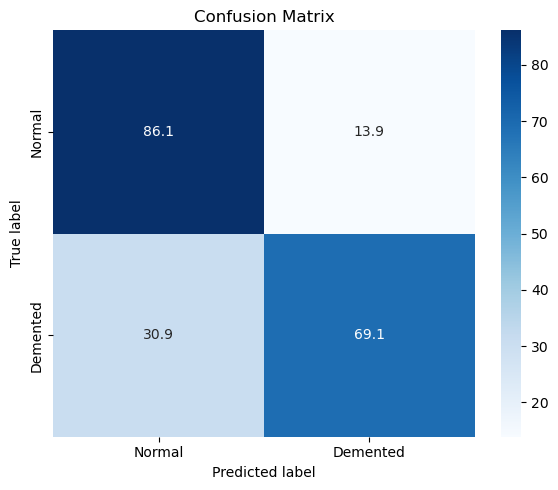

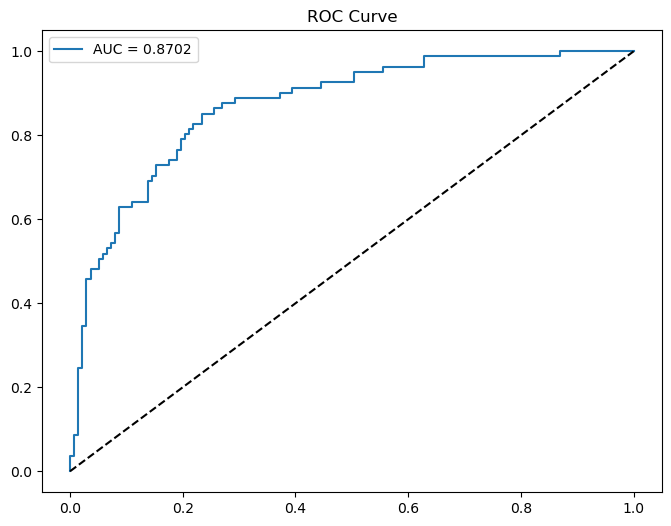

In [19]:
final_model.load_state_dict(
    torch.load("best_medicalnet_finetuned.pth", map_location=DEVICE)
)

test_metrics = test_model(final_model, final_test_loader, DEVICE, plot=True, save=True)


## 14 · Export Optuna Results


In [20]:
trials_df = study.trials_dataframe()
trials_df.to_csv("optuna_trials_medicalnet.csv", index=False)
print("Saved optuna_trials_medicalnet.csv")
display(trials_df.sort_values("value", ascending=False).head(10))


Saved optuna_trials_medicalnet.csv


,number,value,datetime_start,datetime_complete,duration,params_augment,params_batch_size,params_dropout,params_fc_units,params_lr,params_n_fc_layers,state
18,18,0.530185,2026-06-10 21:40:20.055604,2026-06-10 21:42:48.374372,0 days 00:02:28.318768,False,4,0.324577,320,0.007047,0,COMPLETE
13,13,0.522757,2026-06-10 21:27:53.803420,2026-06-10 21:30:23.532713,0 days 00:02:29.729293,False,8,0.284511,256,0.008340,0,COMPLETE
10,10,0.507821,2026-06-10 21:20:26.487003,2026-06-10 21:22:55.473562,0 days 00:02:28.986559,False,8,0.305432,256,0.007441,0,COMPLETE
11,11,0.495198,2026-06-10 21:22:55.473950,2026-06-10 21:25:24.537073,0 days 00:02:29.063123,False,8,0.298107,256,0.009916,0,COMPLETE
24,24,0.472299,2026-06-10 21:55:11.084290,2026-06-10 21:57:41.346116,0 days 00:02:30.261826,False,8,0.374219,320,0.003101,0,COMPLETE
12,12,0.469904,2026-06-10 21:25:24.537417,2026-06-10 21:27:53.803059,0 days 00:02:29.265642,False,8,0.258431,256,0.009865,0,COMPLETE
15,15,0.467954,2026-06-10 21:32:53.234776,2026-06-10 21:35:21.572216,0 days 00:02:28.337440,False,4,0.229078,256,0.004975,0,COMPLETE
3,3,0.457737,2026-06-10 21:03:04.746990,2026-06-10 21:05:34.061322,0 days 00:02:29.314332,False,8,0.392951,512,0.000308,0,COMPLETE
16,16,0.451802,2026-06-10 21:35:21.572591,2026-06-10 21:37:50.952244,0 days 00:02:29.379653,False,8,0.342405,128,0.005494,0,COMPLETE
29,29,0.435298,2026-06-10 22:05:44.946319,2026-06-10 22:08:14.889794,0 days 00:02:29.943475,False,4,0.333617,384,0.001749,0,COMPLETE


Young test subset: Age < 75
Number of subjects: 151

Class distribution:
label
Normal      116
Demented     35
Name: count, dtype: int64

Class distribution (%):
label
Normal      76.821192
Demented    23.178808
Name: proportion, dtype: float64

Age mean : 65.7
Age std  : 6.8
Age range: 45.8 - 74.7

===== TEST METRICS =====
Accuracy           : 0.8212
Macro Precision    : 0.7506
Weighted Precision : 0.8134
Macro Recall       : 0.7240
Weighted Recall    : 0.8212
Macro F1-score     : 0.7353
Weighted F1-score  : 0.8162
ROC AUC            : 0.8446
              precision    recall  f1-score   support

      Normal     0.8678    0.9052    0.8861       116
    Demented     0.6333    0.5429    0.5846        35

    accuracy                         0.8212       151
   macro avg     0.7506    0.7240    0.7353       151
weighted avg     0.8134    0.8212    0.8162       151



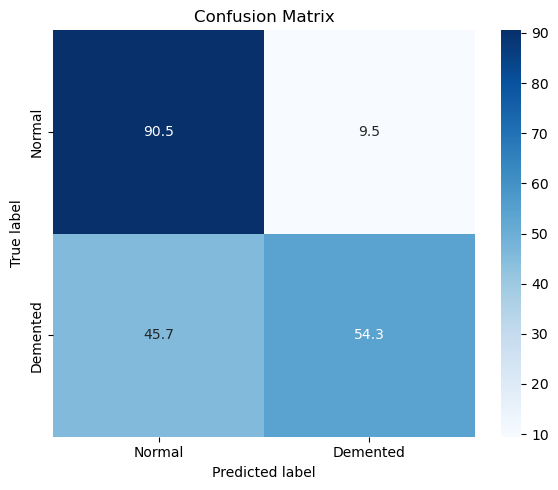

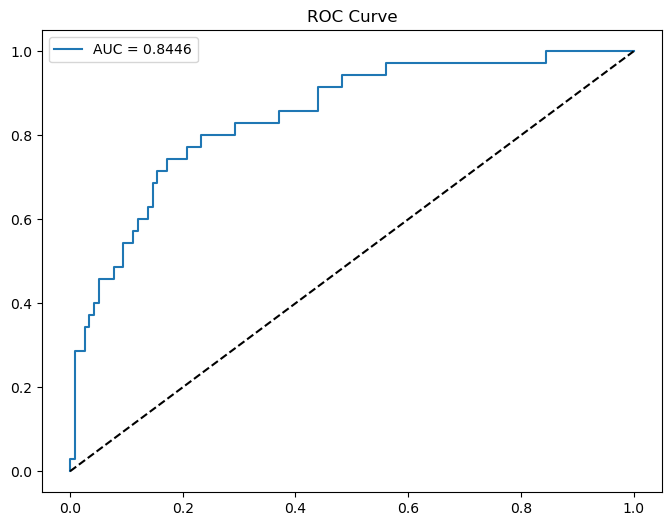


===== YOUNG TEST METRICS DICT =====
{'accuracy': 0.8211920529801324, 'precision_macro': 0.7505509641873278, 'precision_weighted': 0.8134292959699342, 'recall_macro': 0.7240147783251232, 'recall_weighted': 0.8211920529801324, 'f1_macro': 0.7353456669912366, 'f1_weighted': 0.8162009840272897, 'auc': 0.8445812807881774}


In [21]:
from torch.utils.data import DataLoader

# =========================================================
# Young Subject Subgroup Analysis
# =========================================================

AGE_THRESHOLD = 75

# Filter only young subjects from the original test set
young_test_df = test_df[test_df["Age"] < AGE_THRESHOLD].copy()

print("=" * 55)
print(f"Young test subset: Age < {AGE_THRESHOLD}")
print("=" * 55)

print(f"Number of subjects: {len(young_test_df)}")
print("\nClass distribution:")
print(young_test_df["label"].value_counts().rename({0: "Normal", 1: "Demented"}))

print("\nClass distribution (%):")
print((young_test_df["label"].value_counts(normalize=True) * 100).rename({0: "Normal", 1: "Demented"}))

print(f"\nAge mean : {young_test_df['Age'].mean():.1f}")
print(f"Age std  : {young_test_df['Age'].std():.1f}")
print(f"Age range: {young_test_df['Age'].min():.1f} - {young_test_df['Age'].max():.1f}")

# Create DataLoader for young test subjects
young_test_loader = DataLoader(
    OASIS3DDataset(young_test_df, augment=False),
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Evaluate model on young test subset
young_test_metrics = test_model(
    final_model,
    young_test_loader,
    DEVICE,
    plot=True,
    save=True
)

print("\n===== YOUNG TEST METRICS DICT =====")
print(young_test_metrics)